# Этап 1. Исследование данных (EDA)

**Задача проекта:** прогнозировать цену жилой недвижимости по характеристикам объявления. Здесь мы изучаем данные до очистки и обучения моделей. Таблицы и графики строятся из файла `data/real_estate_data.csv`; исходный файл не меняется.

**Как читать ноутбук:** после каждой таблицы и каждого графика идёт простое пояснение. Числа относятся к историческим объявлениям, а не к фактическим ценам сделок.

## 1.1. Знакомство с данными

Источник — набор объявлений Zingat; описание полей находится в `data/zingat_data_info.docx`. Целевая переменная — `price` с единицей `price_currency`. Площадь `size` дана в м², `tom` — в днях. `building_age` означает возраст здания, а не год постройки. `address` записан как город/район/микрорайон.

In [2]:
# Загружаем данные; путь работает из корня проекта и из папки notebooks.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42
DATA_PATH = next((p for p in [Path("data/real_estate_data.csv"), Path("../data/real_estate_data.csv")] if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Не найден data/real_estate_data.csv")
df = pd.read_csv(DATA_PATH, low_memory=False)
original_columns = df.columns.tolist()
print(f"Размер: {len(df):,} строк × {len(original_columns)} столбцов")

Размер: 403,487 строк × 17 столбцов


в датасете 403 487 объявлений и 17 исходных признаков. Это достаточно большая выборка для сравнения групп, но качество каждого поля нужно проверить отдельно.

### Типы и заполненность полей

In [3]:
# Таблица показывает формат, число заполненных и число уникальных значений.
schema = pd.DataFrame({"тип": df.dtypes.astype(str),
                       "заполнено": df.notna().sum(),
                       "уникальных": df.nunique(dropna=True)})
display(schema)

,тип,заполнено,уникальных
id,int64,403487,403487
type,object,403487,1
sub_type,object,403487,12
start_date,object,403487,181
end_date,object,266298,181
listing_type,int64,403487,3
tom,int64,403487,181
building_age,object,376097,14
total_floor_count,object,375466,12
floor_no,object,368191,35


**Что видим / вывод:** `price` и `size` числовые, но `building_age`, `room_count`, этажи и даты пока записаны строками. `type` имеет одно значение — «Konut» (жильё); `furnished` вообще не заполнен. Строковые поля потребуется преобразовать перед обучением.

### Примеры записей

In [4]:
# Первые строки позволяют увидеть исходный формат.
display(df.head(5))

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
0,1,Konut,Rezidans,12/10/18,1/9/19,2,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,3500.0,TRY
1,2,Konut,Daire,2/13/19,NaN,1,14,0,20 ve üzeri,20 ve üzeri,1+0,43.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,490000.0,TRY
2,3,Konut,Daire,10/9/18,11/8/18,1,30,0,1,Yüksek Giriş,2+1,NaN,Tekirdağ/Çorlu/Reşadiye,NaN,Fancoil,155000.0,TRY
3,4,Konut,Rezidans,9/10/18,10/10/18,1,30,3,20 ve üzeri,20 ve üzeri,6+1,450.0,İstanbul/Beşiktaş/Levent,NaN,Fancoil,32500000.0,TRY
4,5,Konut,Rezidans,12/10/18,1/9/19,1,30,0,20 ve üzeri,2,2+1,90.0,İstanbul/Kartal/Kordonboyu,NaN,Fancoil,1450000.0,TRY


встречаются и низкие, и высокие цены, разные валюты и пустая площадь. Нельзя считать, что все строки описывают один и тот же рынок.

In [5]:
# Последние строки помогают увидеть, одинаков ли формат в конце файла.
display(df.tail(5))

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
403482,403483,Konut,Daire,9/18/18,NaN,2,162,NaN,NaN,NaN,+,NaN,İstanbul/Sultanbeyli/Adil,NaN,NaN,1500.0,TRY
403483,403484,Konut,Daire,10/11/18,NaN,1,139,NaN,NaN,NaN,2+1,NaN,Sakarya/Adapazarı/Cumhuriyet,NaN,NaN,120000.0,TRY
403484,403485,Konut,Daire,11/22/18,NaN,1,97,NaN,NaN,NaN,1+1,NaN,Antalya/Alanya/Saray,NaN,NaN,48000.0,EUR
403485,403486,Konut,Daire,2/21/19,NaN,2,6,NaN,NaN,NaN,2+1,2.0,Aydın/Kuşadası/Türkmen,NaN,NaN,900.0,TRY
403486,403487,Konut,Daire,1/15/19,1/18/19,1,3,NaN,NaN,NaN,3+1,140.0,Kayseri/Melikgazi/Alpaslan,NaN,NaN,210000.0,TRY


структура столбцов сохраняется, но встречаются записи с `room_count='+'` и пропущенной площадью — нужен контроль качества.

In [6]:
# Случайная строка воспроизводима благодаря фиксированному seed.
display(df.sample(1, random_state=RANDOM_STATE))

,id,type,sub_type,start_date,end_date,listing_type,tom,building_age,total_floor_count,floor_no,room_count,size,address,furnished,heating_type,price,price_currency
60623,60624,Konut,Daire,11/20/18,2/23/19,1,95,6-10 arası,5,1,2+1,120.0,Antalya/Alanya/Oba,NaN,Klima,240000.0,TRY


поле `room_count` выглядит как «2+1» (две комнаты и гостиная), а `building_age` может быть диапазоном вроде «6-10 arası».

In [7]:
# Даты публикации парсим в явном формате месяц/день/год.
dates = pd.to_datetime(df.start_date, format="%m/%d/%y", errors="coerce")
print("Период:", dates.min().date(), "—", dates.max().date())
display(df.price_currency.value_counts(dropna=False).to_frame("объявлений"))

Период: 2018-08-31 — 2019-02-27


,объявлений
price_currency,
TRY,400677
EUR,922
NaN,715
GBP,621
USD,552


объявления опубликованы с 31.08.2018 по 27.02.2019. Основная валюта — TRY, но также есть EUR, GBP и USD. Цены разных валют без пересчёта сравнивать нельзя; исторический период ограничивает применимость модели к сегодняшнему рынку.

## 1.2. Описательная статистика

Числовая сводка показывает центр распределения и крайние значения. `id` и `listing_type` технически числа, но по смыслу идентификатор и код категории; их среднее значение не интерпретируется.

In [8]:
# Считаем минимум, квартили, медиану, среднее, максимум и стандартное отклонение.
numeric_summary = df.select_dtypes(include="number").describe(percentiles=[.25, .5, .75]).T
display(numeric_summary[["count","min","25%","50%","mean","75%","max","std"]])

,count,min,25%,50%,mean,75%,max,std
id,403487.0,1.0,100872.5,201744.0,201744.000000,302615.5,4.034870e+05,1.164768e+05
listing_type,403487.0,1.0,1.0,1.0,1.294235,2.0,3.000000e+00,4.677333e-01
tom,403487.0,0.0,29.0,40.0,57.022739,90.0,1.800000e+02,4.435893e+01
size,257481.0,1.0,85.0,110.0,279.349094,140.0,9.482350e+05,9.429195e+03
furnished,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,402772.0,-250.0,2500.0,199000.0,354641.661933,342000.0,2.000000e+09,4.809503e+06


цена достигает отрицательных значений и экстремально высоких сумм; площадь — до 948 235 м². Поэтому средние сильно зависят от выбросов. Для описания «типичного» объекта полезнее медиана и квартили.

In [9]:
# Считаем число категорий и наиболее частое значение для каждого текстового поля.
categorical_cols = df.select_dtypes(include=["object"]).columns
category_summary = pd.DataFrame({
    "уникальных": df[categorical_cols].nunique(dropna=True),
    "наиболее частое": [df[x].mode(dropna=True).iloc[0] if df[x].notna().any() else None for x in categorical_cols],
    "частота": [df[x].value_counts(dropna=True).iloc[0] if df[x].notna().any() else 0 for x in categorical_cols]
}, index=categorical_cols)
display(category_summary)

,уникальных,наиболее частое,частота
type,1,Konut,403487
sub_type,12,Daire,354549
start_date,181,10/11/18,4064
end_date,181,12/19/18,3048
building_age,14,0,140174
total_floor_count,12,4,83082
floor_no,35,2,65864
room_count,37,3+1,157363
address,7842,Balıkesir/Edremit/Akçay,5611
heating_type,16,Kombi (Doğalgaz),204150


адрес имеет тысячи значений, поэтому прямое one-hot-кодирование полного адреса будет громоздким. Самый частый тип жилья — квартира (`Daire`), наиболее частая конфигурация — `3+1`. Это стоит учитывать при сравнении средних по группам.

### Частоты важных категорий

In [10]:
# Показываем частоты подтипов жилья.
display(df.sub_type.value_counts(dropna=False).to_frame("объявлений"))

,объявлений
sub_type,
Daire,354549
Villa,21324
Müstakil Ev,9563
Rezidans,7716
Yazlık,5929
Komple Bina,2607
Prefabrik Ev,679
Çiftlik Evi,528
Köşk / Konak / Yalı,301


квартир намного больше, чем вилл и других подтипов. Сравнение групп должно сопровождаться числом объявлений, иначе маленькая группа может дать нестабильную оценку.

In [11]:
# Показываем наиболее частые конфигурации комнат.
display(df.room_count.value_counts(dropna=False).head(12).to_frame("объявлений"))

,объявлений
room_count,
3+1,157363
2+1,138677
1+1,39134
4+1,37472
5+1,8219
4+2,4540
5+2,2926
+,2898
3+2,2673


`3+1` и `2+1` доминируют. Есть значение `+`, из которого число комнат не извлечь — оно станет пропуском после преобразования.

In [12]:
# Возраст здания бывает числом или интервалом.
display(df.building_age.value_counts(dropna=False).to_frame("объявлений"))

,объявлений
building_age,
0,140174
6-10 arası,50495
11-15 arası,32309
16-20 arası,31333
NaN,27390
1,20355
4,19032
21-25 arası,18438
2,17466


0 лет — самая частая запись; часть возраста дана диапазонами. Точный год постройки в наборе не указан. Ниже диапазоны временно заменяются серединами только для EDA.

### Почему выделяем сопоставимый сегмент

In [13]:
# Сравниваем медианные цены по коду типа объявления и валюте.
display(df.groupby(["listing_type","price_currency"],dropna=False).price.agg(["count","median"]))

count    median
listing_type price_currency                  
1            EUR                891   85000.0
             GBP                581   75000.0
             TRY             284496  270000.0
             USD                452  635000.0
             NaN                  0       NaN
2            EUR                 31     900.0
             GBP                 40     400.0
             TRY             113948    1200.0
             USD                 99    2500.0
             NaN                  0       NaN
3            TRY               2233      70.0
             USD                  1     569.0
             NaN                  0       NaN

медиана для кода `listing_type=1` и TRY — 270 000, для кода 2 — 1 200. Это согласуется с продажей и арендой соответственно, но числовые коды не объяснены в словаре. Интерпретация кода 1 как продажи остаётся предположением до подтверждения источником.

In [14]:
# Оставляем код 1, TRY и положительные цены; исходный df остаётся неизменным.
sale = df.loc[(df.listing_type == 1) & (df.price_currency == "TRY") & (df.price > 0)].copy()
sale["city"] = sale.address.str.split("/").str[0]
sale["district"] = sale.address.str.split("/").str[1]
sale["rooms"] = pd.to_numeric(sale.room_count.str.split("+", regex=False).str[0], errors="coerce")
age_map = {"6-10 arası":8,"11-15 arası":13,"16-20 arası":18,"21-25 arası":23,
           "26-30 arası":28,"31-35 arası":33,"36-40 arası":38,"40 ve üzeri":42}
sale["age_approx"] = pd.to_numeric(sale.building_age.replace(age_map), errors="coerce")
sale["size_valid"] = sale["size"].where(sale["size"].between(15,1000))
sale["log_price"] = np.log10(sale.price)
print(f"Сопоставимый сегмент: {len(sale):,} объявлений")
display(sale[["price","size_valid","rooms","age_approx"]].describe(percentiles=[.01,.25,.5,.75,.99]).T)

Сопоставимый сегмент: 284,468 объявлений


,count,mean,std,min,1%,25%,50%,75%,99%,max
price,284468.0,491812.881909,5.310471e+06,1.0,63500.0,185000.0,270000.0,420000.0,3700000.0,2.000000e+09
size_valid,182972.0,127.847594,7.175556e+01,15.0,45.0,90.0,115.0,145.0,400.0,1.000000e+03
rooms,282563.0,2.733270,1.048669e+00,0.0,1.0,2.0,3.0,3.0,6.0,1.100000e+01
age_approx,267492.0,5.861484,8.226323e+00,0.0,0.0,0.0,2.0,8.0,33.0,4.200000e+01


284 468 объявлений с положительной ценой в TRY. Медиана — 270 000 TRY, а среднее — около 492 000 TRY: его поднимают дорогие объявления. Медианная допустимая площадь — 115 м². Отбор площади 15–1000 м² здесь нужен только для понятных графиков, это ещё не окончательное правило очистки.

In [15]:
# Коэффициент асимметрии измеряет длину правого хвоста цены.
print("Асимметрия цены:", round(sale.price.skew(), 2))

Асимметрия цены: 297.66


коэффициент асимметрии около 297,66 — распределение цены сильно скошено вправо. В такой ситуации полезно смотреть цену в логарифмическом масштабе и отдельно анализировать крайне дорогие объекты.

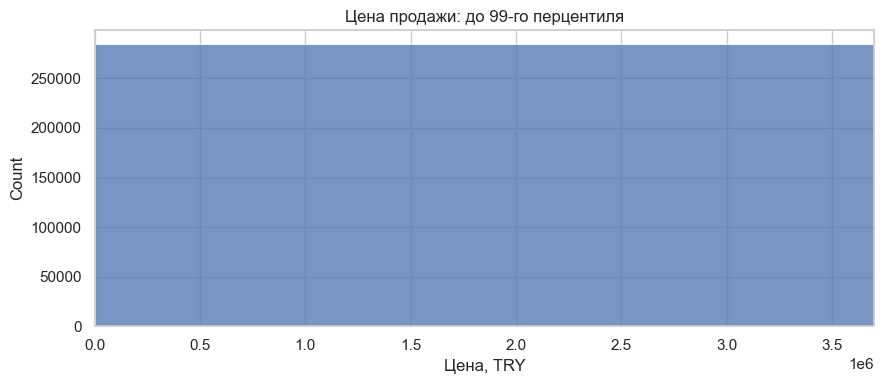

In [16]:
# Гистограмма с ограничением оси до 99-го перцентиля для читаемости.
plt.figure(figsize=(9,4))
sns.histplot(sale.price, bins=80)
plt.xlim(0,sale.price.quantile(.99)); plt.xlabel("Цена, TRY")
plt.title("Цена продажи: до 99-го перцентиля")
plt.tight_layout(); plt.show()

большинство объявлений сосредоточено на низких и средних ценах; справа остаётся длинный хвост. Ограничение оси скрывает только отображение верхнего 1%, данные не удалены.

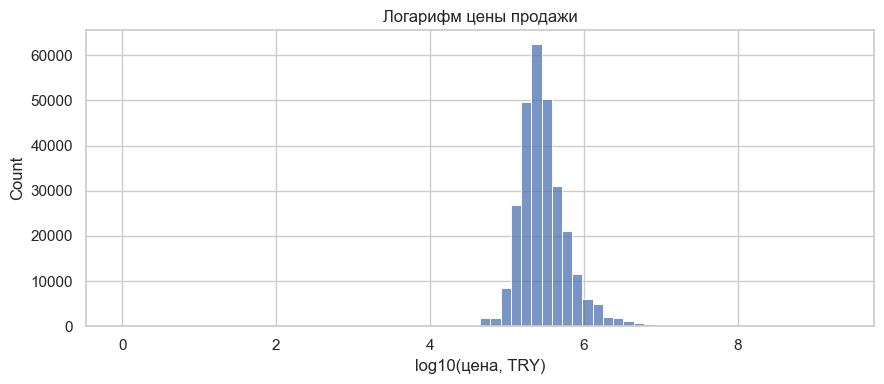

In [17]:
# Логарифмическая шкала раскрывает форму основного распределения.
plt.figure(figsize=(9,4))
sns.histplot(sale.log_price,bins=70)
plt.xlabel("log10(цена, TRY)"); plt.title("Логарифм цены продажи")
plt.tight_layout(); plt.show()

после преобразования основная масса цен видна лучше. Это аргумент проверить логарифмирование целевой переменной при моделировании, но качество нужно оценивать в исходных TRY.

## 1.3. Визуальный анализ

Пять типов визуализации: гистограммы, диаграммы рассеяния, boxplot, тепловая карта и столбчатые диаграммы. Каждый график отвечает на один вопрос. Для читаемости некоторые оси ограничены, а scatter использует фиксированную подвыборку; исходные данные от этого не меняются.

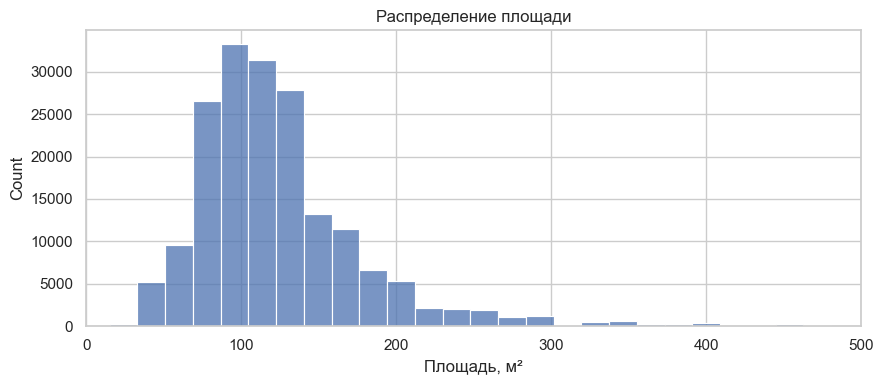

In [18]:
# Площадь: показываем правдоподобные записанные значения, без пропусков.
plt.figure(figsize=(9,4))
sns.histplot(sale.size_valid.dropna(),bins=55)
plt.xlim(0,500); plt.xlabel("Площадь, м²"); plt.title("Распределение площади")
plt.tight_layout(); plt.show()

основная масса объявлений описывает объекты примерно среднего размера; медиана среди допустимых записей — 115 м². Длинный правый хвост означает, что большие дома и здания нужно анализировать с учётом типа жилья.

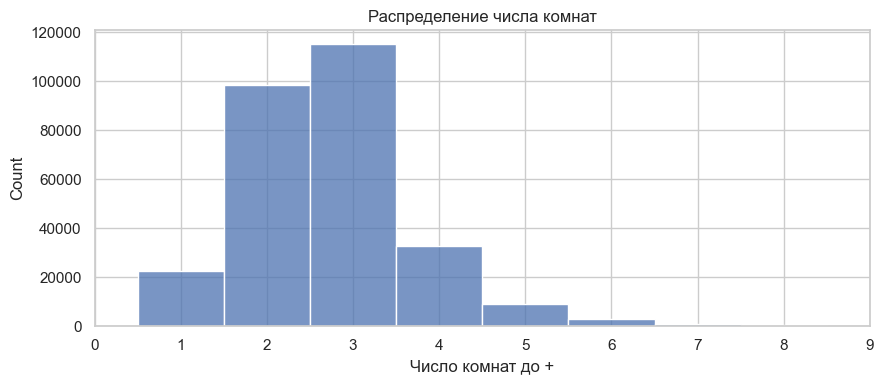

In [19]:
# Количество комнат: число до знака «+».
plt.figure(figsize=(9,4))
sns.histplot(sale.rooms.dropna(),discrete=True)
plt.xlim(0,9); plt.xlabel("Число комнат до +"); plt.title("Распределение числа комнат")
plt.tight_layout(); plt.show()

наиболее типичны 2–3 комнаты. Значение вроде `3+1` здесь превращено в 3; гостиная отдельно не учитывается. Записи вида `+` становятся пропусками.

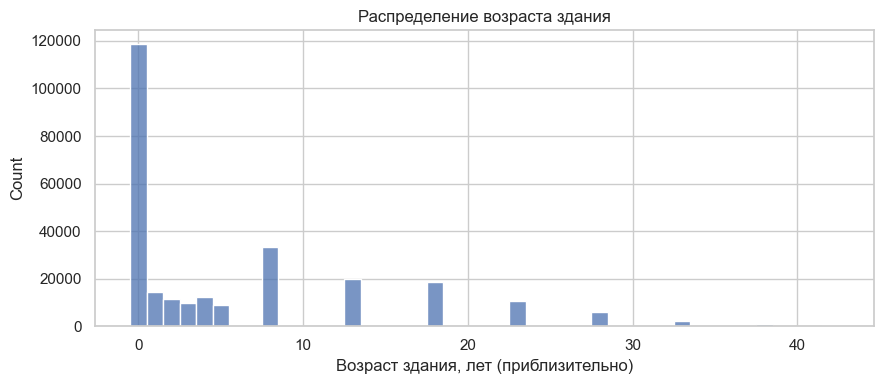

In [20]:
# Интервалы возраста заменены серединами для ориентировочного графика.
plt.figure(figsize=(9,4))
sns.histplot(sale.age_approx.dropna(),discrete=True)
plt.xlabel("Возраст здания, лет (приблизительно)")
plt.title("Распределение возраста здания")
plt.tight_layout(); plt.show()

много объявлений с возрастом 0 лет. Пики на 8, 13, 18 и других значениях частично созданы заменой диапазонов их серединами; это не точные годы постройки.

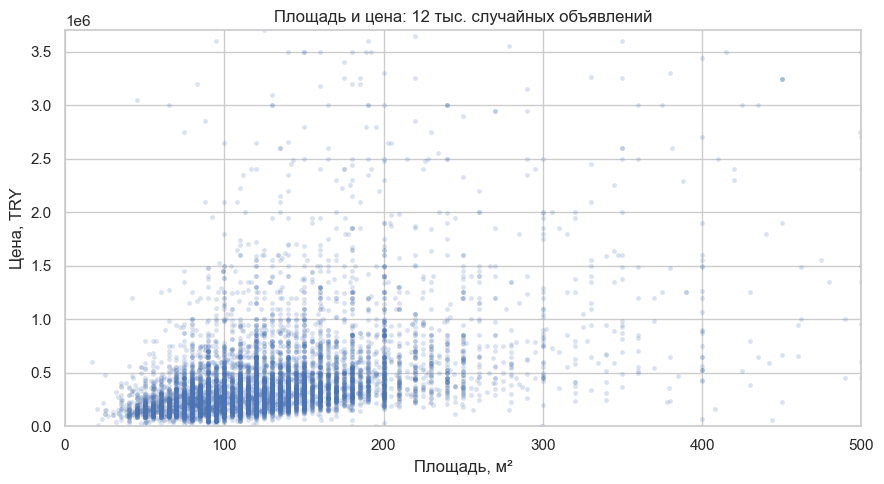

In [21]:
# Случайная подвыборка фиксирована, чтобы рисунок был воспроизводим.
sample = sale.loc[sale.size_valid.notna()].sample(n=min(12000,sale.size_valid.notna().sum()),random_state=RANDOM_STATE)
plt.figure(figsize=(9,5))
sns.scatterplot(data=sample,x="size_valid",y="price",alpha=.2,s=12,linewidth=0)
plt.xlim(0,500); plt.ylim(0,sale.price.quantile(.99))
plt.xlabel("Площадь, м²"); plt.ylabel("Цена, TRY")
plt.title("Площадь и цена: 12 тыс. случайных объявлений")
plt.tight_layout(); plt.show()

в целом более просторное жильё дороже, но при одной площади цены сильно различаются. Значит, одной площади для прогноза недостаточно — важны локация, тип объекта и другие характеристики.

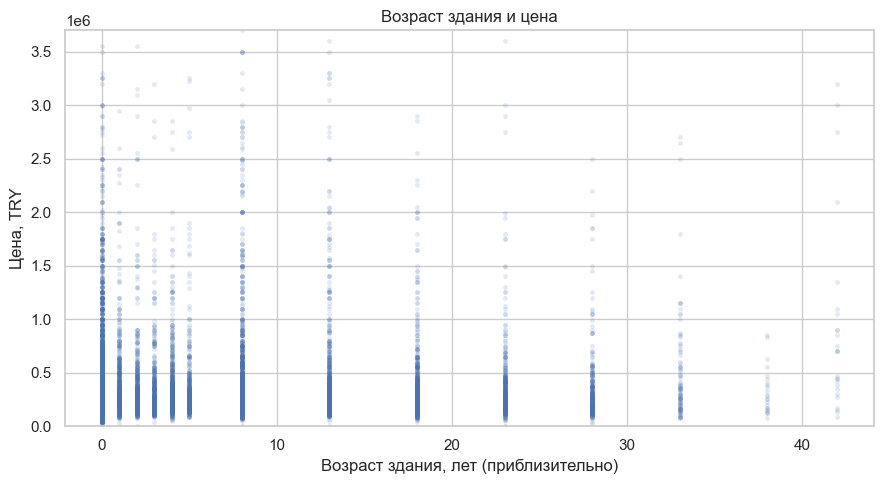

In [22]:
# Проверяем, видна ли прямая связь возраста здания с ценой.
age_sample = sale.loc[sale.age_approx.notna()].sample(n=min(12000,sale.age_approx.notna().sum()),random_state=RANDOM_STATE)
plt.figure(figsize=(9,5))
sns.scatterplot(data=age_sample,x="age_approx",y="price",alpha=.15,s=12,linewidth=0)
plt.ylim(0,sale.price.quantile(.99))
plt.xlabel("Возраст здания, лет (приблизительно)"); plt.ylabel("Цена, TRY")
plt.title("Возраст здания и цена")
plt.tight_layout(); plt.show()

явной прямой зависимости на общей выборке не видно. Возраст может влиять по-разному в разных городах и типах жилья; проверим это при моделировании.

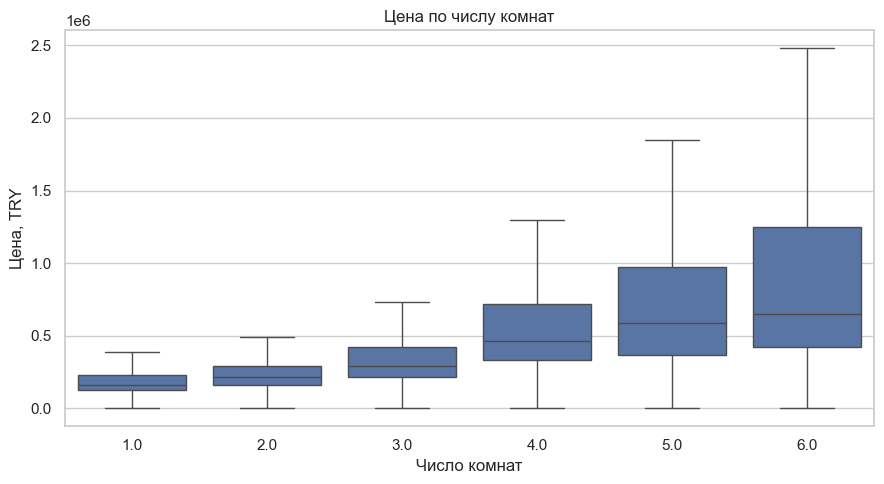

In [23]:
# Boxplot показывает медиану, квартили и разброс цен по комнатам.
limited = sale.loc[sale.price.le(sale.price.quantile(.99)) & sale.rooms.between(1,6)]
plt.figure(figsize=(9,5))
sns.boxplot(data=limited,x="rooms",y="price",showfliers=False)
plt.xlabel("Число комнат"); plt.ylabel("Цена, TRY")
plt.title("Цена по числу комнат")
plt.tight_layout(); plt.show()

медиана цены обычно растёт с числом комнат, но диапазоны разных групп сильно перекрываются. Число комнат полезно, однако само по себе не определяет цену. Точки выбросов скрыты для читаемости, строки сохранены.

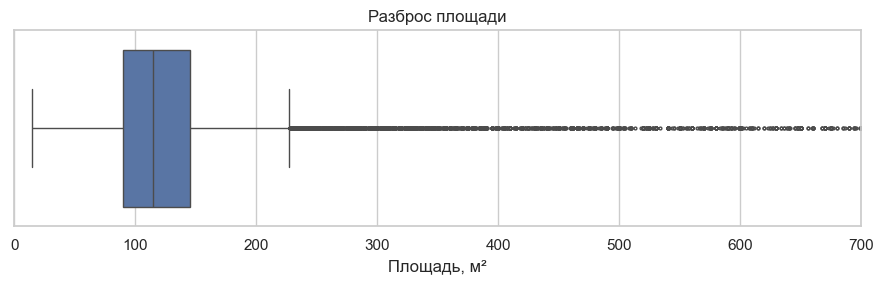

In [24]:
# Boxplot площади показывает потенциальные выбросы по правилу 1,5×IQR.
plt.figure(figsize=(9,3))
sns.boxplot(x=sale.size_valid.dropna(),showfliers=True,flierprops={"markersize":2})
plt.xlim(0,700); plt.xlabel("Площадь, м²")
plt.title("Разброс площади")
plt.tight_layout(); plt.show()

выше верхнего «уса» есть крупные объекты. Часть может быть реальной (например, виллы), поэтому автоматически удалять их нельзя. Сначала нужно проверить тип жилья и достоверность площади.

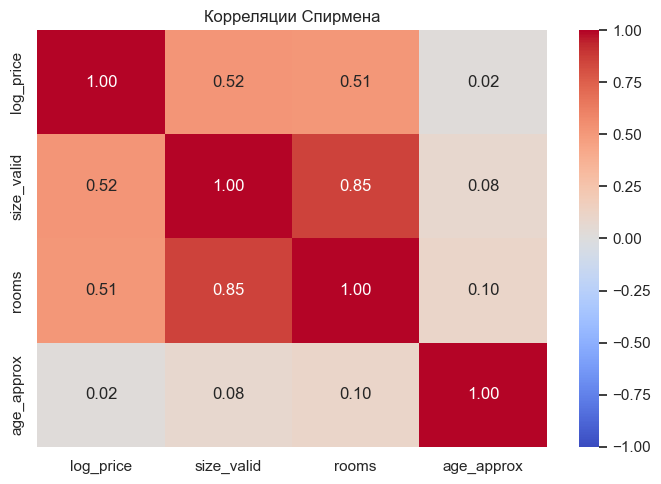

In [25]:
# Спирмен оценивает монотонную связь, не требуя нормальности цены.
corr = sale[["log_price","size_valid","rooms","age_approx"]].corr(method="spearman")
plt.figure(figsize=(7,5))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",center=0,vmin=-1,vmax=1)
plt.title("Корреляции Спирмена")
plt.tight_layout(); plt.show()

цена связана с площадью (ρ≈0,52) и комнатами (ρ≈0,51). Площадь и комнаты сильно связаны между собой (ρ≈0,85), что важно для линейной регрессии. Общая корреляция возраста с ценой около 0,02 — почти нулевая.

In [26]:
# Таблица содержит точные коэффициенты для доклада.
display(corr.round(3))

,log_price,size_valid,rooms,age_approx
log_price,1.000,0.519,0.512,0.018
size_valid,0.519,1.000,0.852,0.085
rooms,0.512,0.852,1.000,0.105
age_approx,0.018,0.085,0.105,1.000


округлённые значения на карте удобны для показа, а таблица даёт точность для отчёта. Корреляция показывает связь, но не доказывает причинность.

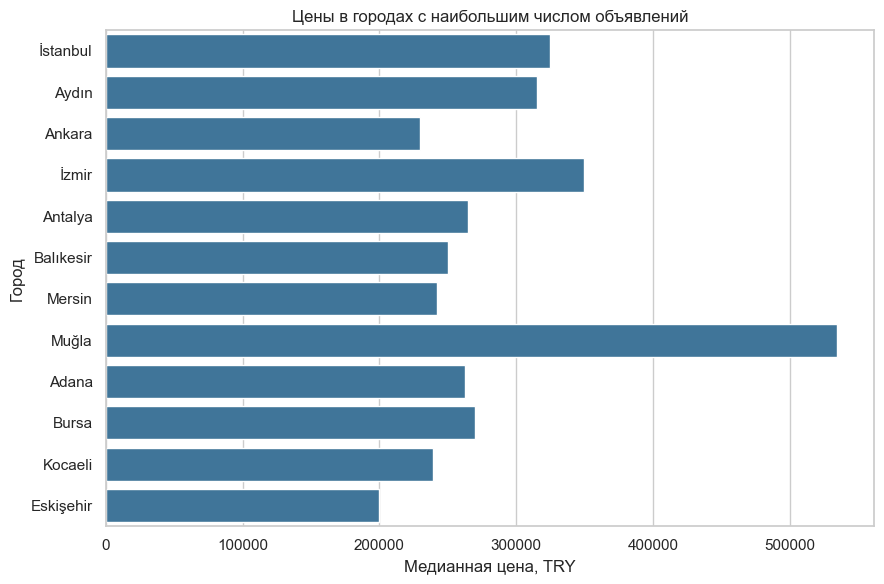

In [27]:
# Группы минимум с 500 объявлениями; медиана устойчива к редким дорогим объектам.
city_stats = sale.groupby("city").price.agg(["count","median","mean"]).query("count >= 500").sort_values("count",ascending=False).head(12)
plt.figure(figsize=(9,6))
sns.barplot(x=city_stats["median"],y=city_stats.index,color="#3178a8")
plt.xlabel("Медианная цена, TRY"); plt.ylabel("Город")
plt.title("Цены в городах с наибольшим числом объявлений")
plt.tight_layout(); plt.show()

медианная цена отличается: например, Мугла — 535 тыс. TRY, Анкара — 230 тыс. TRY. Местоположение должно входить в модель. Это сравнение не учитывает различия состава жилья между городами.

In [28]:
# Сопровождаем график числом записей и средними значениями.
display(city_stats)

,count,median,mean
city,,,
İstanbul,70697,325000.0,8.031079e+05
Aydın,30060,315000.0,4.106377e+05
Ankara,24898,230000.0,3.179637e+05
İzmir,18886,350000.0,5.646129e+05
Antalya,17242,265000.0,4.019302e+05
Balıkesir,11684,250000.0,3.621557e+05
Mersin,8873,242000.0,5.427194e+05
Muğla,8172,535000.0,1.010546e+06
Adana,8067,263000.0,3.441515e+05


в Стамбуле больше всего объявлений — 70 697. Среднее нередко выше медианы из-за дорогих объектов, поэтому для сравнения «типичного» жилья на графике использована медиана.

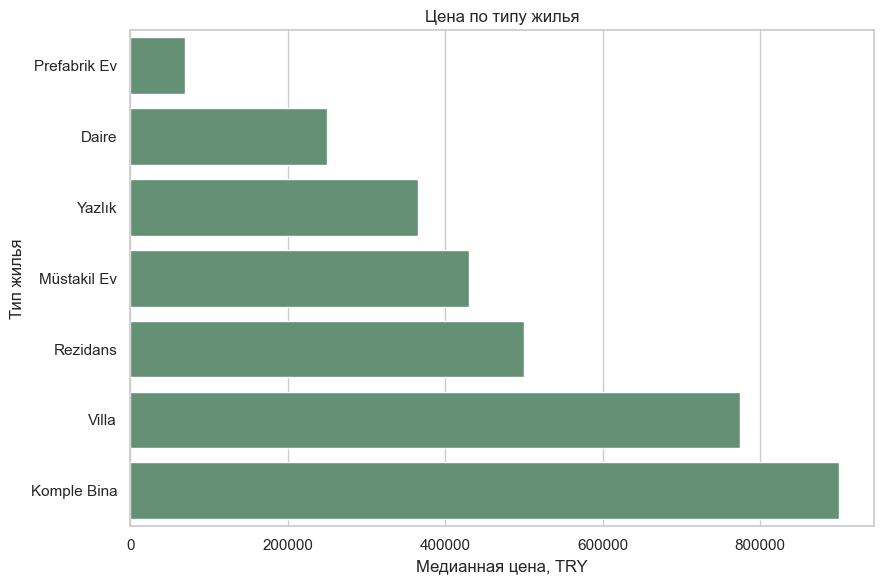

In [29]:
# Сравниваем типы жилья при достаточном числе записей.
type_stats = sale.groupby("sub_type").price.agg(["count","median","mean"]).query("count >= 500").sort_values("median")
plt.figure(figsize=(9,6))
sns.barplot(x=type_stats["median"],y=type_stats.index,color="#5d9773")
plt.xlabel("Медианная цена, TRY"); plt.ylabel("Тип жилья")
plt.title("Цена по типу жилья")
plt.tight_layout(); plt.show()

медианная цена квартир — 250 тыс. TRY, вилл — 775 тыс. TRY. Тип объекта связан с ценой, но виллы обычно также больше по площади и находятся в других локациях.

In [30]:
# Таблица позволяет проверить размер групп и среднюю цену.
display(type_stats)

,count,median,mean
sub_type,,,
Prefabrik Ev,673,69500.0,8.518158e+04
Daire,244914,250000.0,3.547808e+05
Yazlık,5741,365000.0,4.289521e+05
Müstakil Ev,7899,430000.0,7.537826e+05
Rezidans,4249,500000.0,1.319870e+06
Villa,17906,775000.0,1.449676e+06
Komple Bina,2209,900000.0,2.672778e+06


квартиры составляют основную массу сегмента (244 914 записей), а другие группы гораздо меньше. Для редких типов оценки менее устойчивы; ниже порога 500 их нет на графике.

Наиболее явные кандидаты для модели — площадь, число комнат, локация и тип жилья. Возраст здания требует проверки вместе с другими признаками. Ни один отдельный график не заменяет оценку модели на отложенной выборке.

## 1.4. Пропуски и аномалии

Проверяем исходный датасет целиком. В этом разделе ничего не удаляем. Обработку пропусков и выбросов выполним на этапе 2 после разделения данных.

In [31]:
# Считаем пустые значения в каждом исходном столбце.
missing = pd.DataFrame({"пропусков":df[original_columns].isna().sum(),
                        "доля_%":df[original_columns].isna().mean().mul(100)}).sort_values("доля_%",ascending=False)
display(missing.round(2))

,пропусков,доля_%
furnished,403487,100.00
size,146006,36.19
end_date,137189,34.00
floor_no,35296,8.75
total_floor_count,28021,6.94
heating_type,27970,6.93
building_age,27390,6.79
price_currency,715,0.18
price,715,0.18
id,0,0.00


`furnished` пуст у всех 403 487 объектов. Площадь отсутствует у 146 006 (36,19%), `end_date` — у 137 189 (34%). Цены нет у 715 строк. Способ заполнения площади потребует проверки, потому что пропусков много.

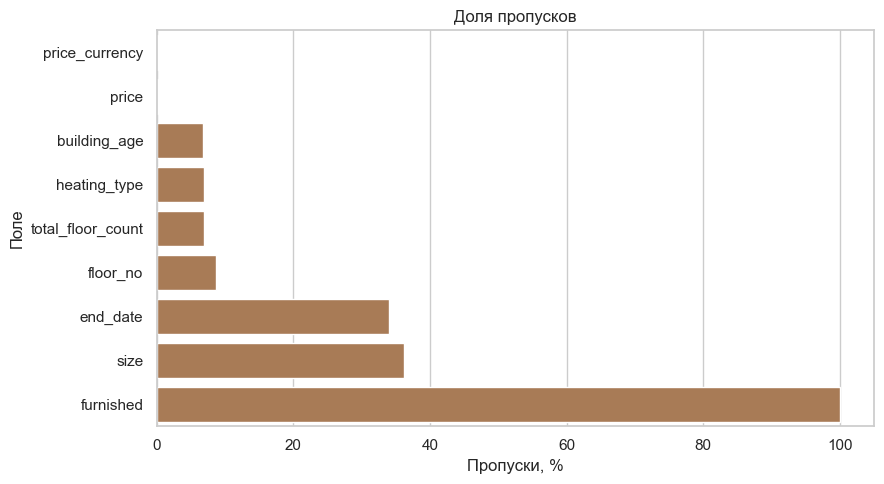

In [32]:
# График выделяет поля с ненулевой долей пропусков.
mplot = missing.loc[missing["доля_%"].gt(0)].sort_values("доля_%")
plt.figure(figsize=(9,5))
sns.barplot(x=mplot["доля_%"],y=mplot.index,color="#b67a48")
plt.xlabel("Пропуски, %"); plt.ylabel("Поле"); plt.title("Доля пропусков")
plt.tight_layout(); plt.show()

главные проблемы — полностью пустой `furnished` и часто отсутствующая площадь. `end_date` может отсутствовать у активных объявлений; для прогноза на момент публикации это поле не нужно.

In [33]:
# Проверяем дубликаты, цену, площадь, даты, срок объявления и возраст.
end_dates = pd.to_datetime(df.end_date,format="%m/%d/%y",errors="coerce")
diagnostics = pd.Series({
    "дубликаты_строк":int(df[original_columns].duplicated().sum()),
    "повторные_id":int(df.id.duplicated().sum()),
    "цена_пустая":int(df.price.isna().sum()),
    "цена_неположительная":int(df.price.le(0).sum()),
    "площадь_неположительная":int(df["size"].le(0).sum()),
    "площадь_вне_15_1000":int((df["size"].notna() & ~df["size"].between(15,1000)).sum()),
    "дата_начала_некорректна":int(dates.isna().sum()),
    "дата_окончания_раньше_начала":int((end_dates<dates).sum()),
    "tom_отрицательный":int(df.tom.lt(0).sum()),
    "возраст_не_распознан_среди_заполненных":int((df.building_age.notna() & pd.to_numeric(df.building_age.replace(age_map),errors="coerce").isna()).sum())
})
display(diagnostics.to_frame("количество"))

,количество
дубликаты_строк,0
повторные_id,0
цена_пустая,715
цена_неположительная,45
площадь_неположительная,0
площадь_вне_15_1000,1140
дата_начала_некорректна,0
дата_окончания_раньше_начала,0
tom_отрицательный,0
возраст_не_распознан_среди_заполненных,0


полных дубликатов и повторных ID нет. Найдено 45 неположительных цен и 1 140 указанных площадей вне диагностического диапазона 15–1000 м². Большая площадь может принадлежать вилле или зданию, поэтому сам по себе размер не доказывает ошибку.

In [34]:
# IQR отмечает необычные значения, но не удаляет объекты.
iqr_rows = []
for col,label in [("price","Цена, TRY"),("size_valid","Площадь, м²")]:
    x = sale[col].dropna()
    q1,q3 = x.quantile([.25,.75])
    upper = q3 + 1.5*(q3-q1)
    iqr_rows.append({"признак":label,"Q1":q1,"Q3":q3,"верхняя_граница":upper,"выше_границы":int((x>upper).sum())})
display(pd.DataFrame(iqr_rows).set_index("признак"))

,Q1,Q3,верхняя_граница,выше_границы
признак,,,,
"Цена, TRY",185000.0,420000.0,772500.0,25928
"Площадь, м²",90.0,145.0,227.5,10234


выше статистической границы находятся примерно 25,9 тыс. цен и 10,2 тыс. площадей. Удалять все такие объекты нельзя: это заметно изменит выборку. На этапе 2 проверим их тип и локацию.

## 1.5. Промежуточные выводы и гипотезы

Эти гипотезы поддержаны EDA, но не доказывают причинную связь.

1. **Площадь связана с более высокой ценой.** Scatter и корреляция Спирмена ρ≈0,52; проверим связь внутри городов.
2. **Локация влияет на цену.** Медианы городов различаются: Мугла — 535 тыс. TRY, Анкара — 230 тыс. TRY.
3. **Тип жилья важен.** Медианы квартир и вилл — 250 и 775 тыс. TRY; проверим эффект после учёта площади и города.
4. **Число комнат полезно, но частично повторяет площадь.** Корреляция с ценой ρ≈0,51, с площадью ρ≈0,85.
5. **Возраст здания может влиять в отдельных сегментах.** Общая корреляция с ценой около 0,02, явного общего эффекта пока нет.

**Для следующего этапа:** разделить train/test до обучения импутеров и кодировщиков. Исключить `id`, `end_date`, `tom` и признаки, вычисленные из цены. Код `listing_type=1` уточнить по первоисточнику.